# Nitrogen Spectrophotometric Analysis
This notebooks is written to analyze data from a colorimetric techniqes. The data must be in the proper format to read by this script.

# Import Modules

In [53]:
import numpy as np
from scipy.optimize import curve_fit

# Data input
Replace the data for `stds`, `std_abs`, `sample_name`, and `sample_abs`with your own data. 

In [54]:
# Concentrations of the standards
stds = [0.46, 1.03, 3.02, 6.04]

# Replace the data with the absorbance of your standards before reduction,
# lowest concentration to highest
std_abs1 = [0.023, 0.052, 0.182, 0.292]

# Replace the data with the absorbance of your standards after reduction,
# lowest concentration to highest
std_abs2 = [0.017, 0.035, 0.122, 0.198]

# Replace the data with your sample names, be sure the names are within quotes
sample_name = ["unk sample"]

# Replace the data with the absorbance values for your samples
samples_abs1 = [0.124]
samples_abs2 = [0.256]

# Calibration curve
Now that the data is uploaded we need to perform a linear regression to create the calibration curve. We will use the Beer-Lambert law (or Beer's law), where $A$ is absorbance, $\epsilon$ is the molar absorptivity, $l$ is path length, and $C$ is concentration, to create our calibration curve.  

$$A=\epsilon{l}C$$

We can see that Beer's law is the equation for a straight line with an intercept of zero. Theoretically this makes sense in that if there are no absorbing molecules present then the absorbance should be zero. Realistically this doesn't happen. For example, analytical instruments don't behave ideally (i.e., there is always some background noise in signals) and blank substractions aren't perfect. So our best fit line will include an intercept. A calibration shouldn't go through the origin unless it demonstrated that the intercept is not statistically different than zero by calculating a t-ratio. For our spectrophotometric analysis the intercept will be statistically different than zero so we must include it.

There are many different ways to fit linear models in Python. I've chosen to use the SciPy module just demonstrate a different way of fitting than is found in the ferrozine analysis script.

## Before reduction

In [55]:
# Use SciPy to determine our calibration curve
# define a function for the equation of a straight line
def func(x, p1, p2):
    return x * p1 + p2


# rename the calibration data x and y and select range with data leaving out the nans
x = np.array(stds)
y = np.array(std_abs1)
# run the regression and save the output parameter (slope and intercept) in popt and save the covariance matrix in pcov
popt, pcov = curve_fit(func, x, y, p0=[0.003, 0])
# calculate the coefficient of determination also known as r^2
residuals = y - func(x, popt[0], popt[1])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# intercept
b = popt[1]
# slope
m = popt[0]

# calculate the fit line for plotting
A1fit_line = func(x, m, b)
# print fit parameters and error
print("Calibration equation\t r-squared")
print("y = %.4f*x + %.4f\t %f" % (m, b, r_squared))

# inverse prediction of concentration from absorbance measurements
sample_conc1 = (np.array(samples_abs1) - b) / m

Calibration equation	 r-squared
y = 0.0488*x + 0.0086	 0.980161


## After Reduction

In [56]:
# Use SciPy to determine our calibration curve
# define a function for the equation of a straight line
def func(x, p1, p2):
    return x * p1 + p2


# rename the calibration data x and y and select range with data leaving out the nans
x = np.array(stds)
y = np.array(std_abs2)
# run the regression and save the output parameter (slope and intercept) in popt and save the covariance matrix in pcov
popt, pcov = curve_fit(func, x, y, p0=[0.003, 0])
# calculate the coefficient of determination also known as r^2
residuals = y - func(x, popt[0], popt[1])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# intercept
b = popt[1]
# slope
m = popt[0]

# calculate the fit line for plotting
A2fit_line = func(x, m, b)

# print fit parameters and error
print("Calibration equation\t r-squared")
print("y = %.4f*x + %.4f\t %f" % (m, b, r_squared))

# inverse prediction of concentration from absorbance measurements
sample_conc2 = (np.array(samples_abs2) - b) / m

Calibration equation	 r-squared
y = 0.0329*x + 0.0062	 0.982728


# Print Results

In [57]:
nitrite = sample_conc1
nitrate = sample_conc2 - sample_conc1
print("Sample\t\t\tNitrite (uM)\t\tNitrate (uM)")
for sample in zip(sample_name, nitrite, nitrate):
    print("%s\t\t%.4f\t\t\t%.4f" % (sample[0], sample[1], sample[2]))

Sample			Nitrite (uM)		Nitrate (uM)
unk sample		2.3660			5.2230


# Plot Calibrations

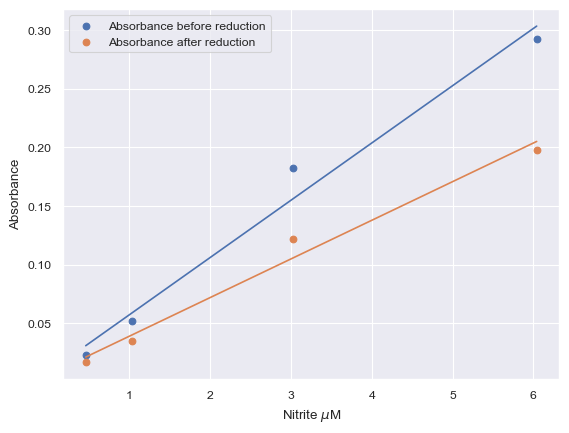

In [58]:
# to plot the data we need to import matlibplot
import matplotlib.pyplot as plt

# to make the plots look nicer we will import the seaborn module
import seaborn as sns

sns.set_theme()
sns.set_context("paper")
# plot the data and label the axes
plt.figure()
plt.scatter(stds, std_abs1, label="Absorbance before reduction")
plt.plot(stds, A1fit_line)
plt.scatter(stds, std_abs2, label="Absorbance after reduction")
plt.plot(stds, A2fit_line)
plt.xlabel(r"Nitrite $\mu$M")
plt.ylabel("Absorbance")
plt.legend()

# Save and download the plot in various file formats
plt.savefig("nitrite_calibration.pdf", bbox_inches="tight")